In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import ast

from config import (
    dataset_dir, 
    dataest_cleaned_name,
)

In [46]:
df = pd.read_csv(dataset_dir / dataest_cleaned_name)
df['production_companies'] = df['production_companies'].apply(
    lambda x: ast.literal_eval(x)
)
df['genres'] = df['genres'].apply(
    lambda x: ast.literal_eval(x)
)

In [47]:
genres_presence = (
    df['genres'].explode()
    .to_frame('genres')
    .assign(id=lambda x: x.index)
    .assign(present=1)
    .pivot_table(values='present', index='id', columns='genres', aggfunc='max', fill_value=0)
)
genres_presence.head()

genres,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
id,,,,,,,,,,,,,,,,,,,
0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0


In [48]:
corr = genres_presence.corr()

mask = np.triu(np.ones_like(corr, dtype=np.bool), k=1)
corr = np.ma.array(corr, mask=mask)

In [49]:
sns.set_theme('notebook')

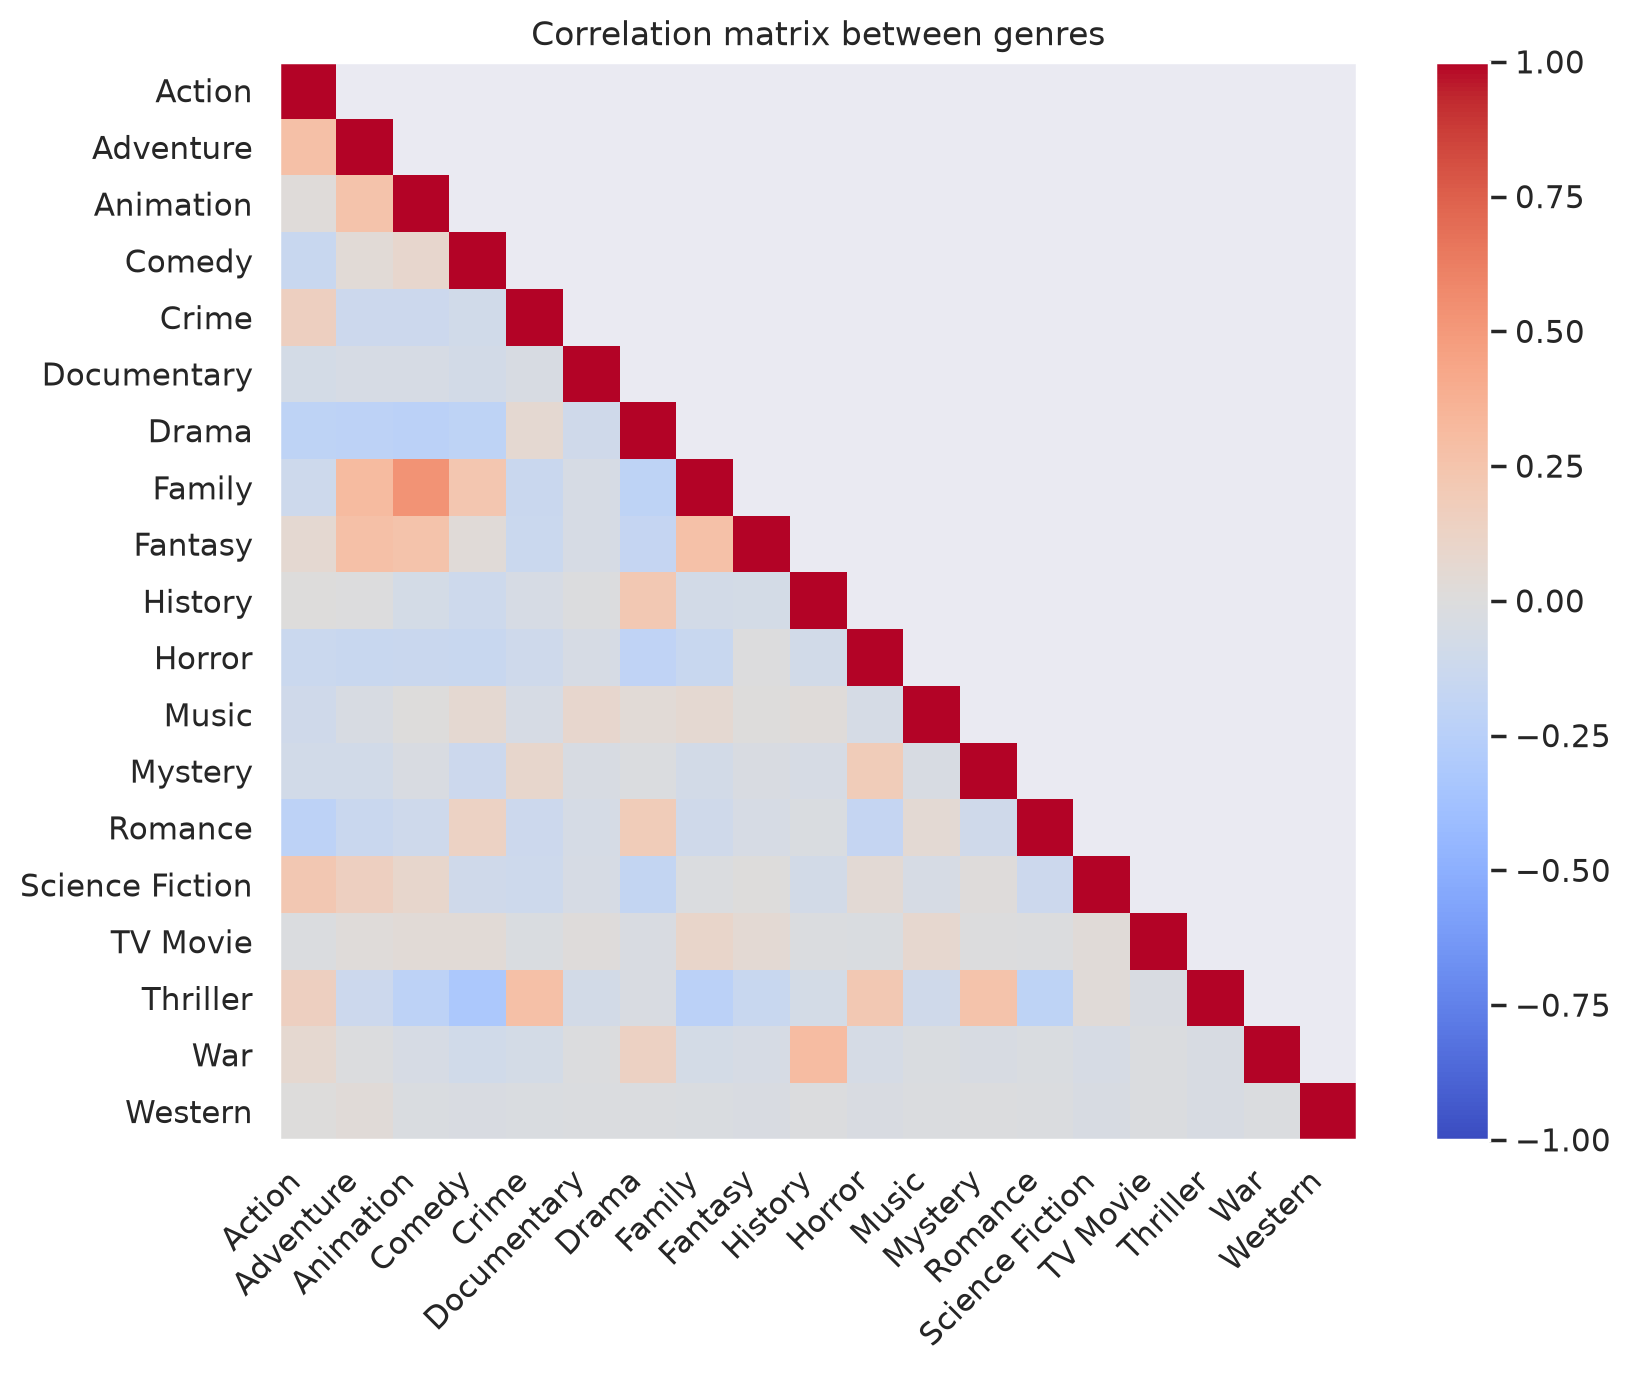

In [50]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
img = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

n = corr.shape[0]
columns = genres_presence.columns.to_list()

ax.grid(False)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))

ax.set_xticklabels(columns, rotation=45, ha='right')
ax.set_yticklabels(columns)

ax.set_title('Correlation matrix between genres')

fig.colorbar(img, ax=ax)

plt.show()

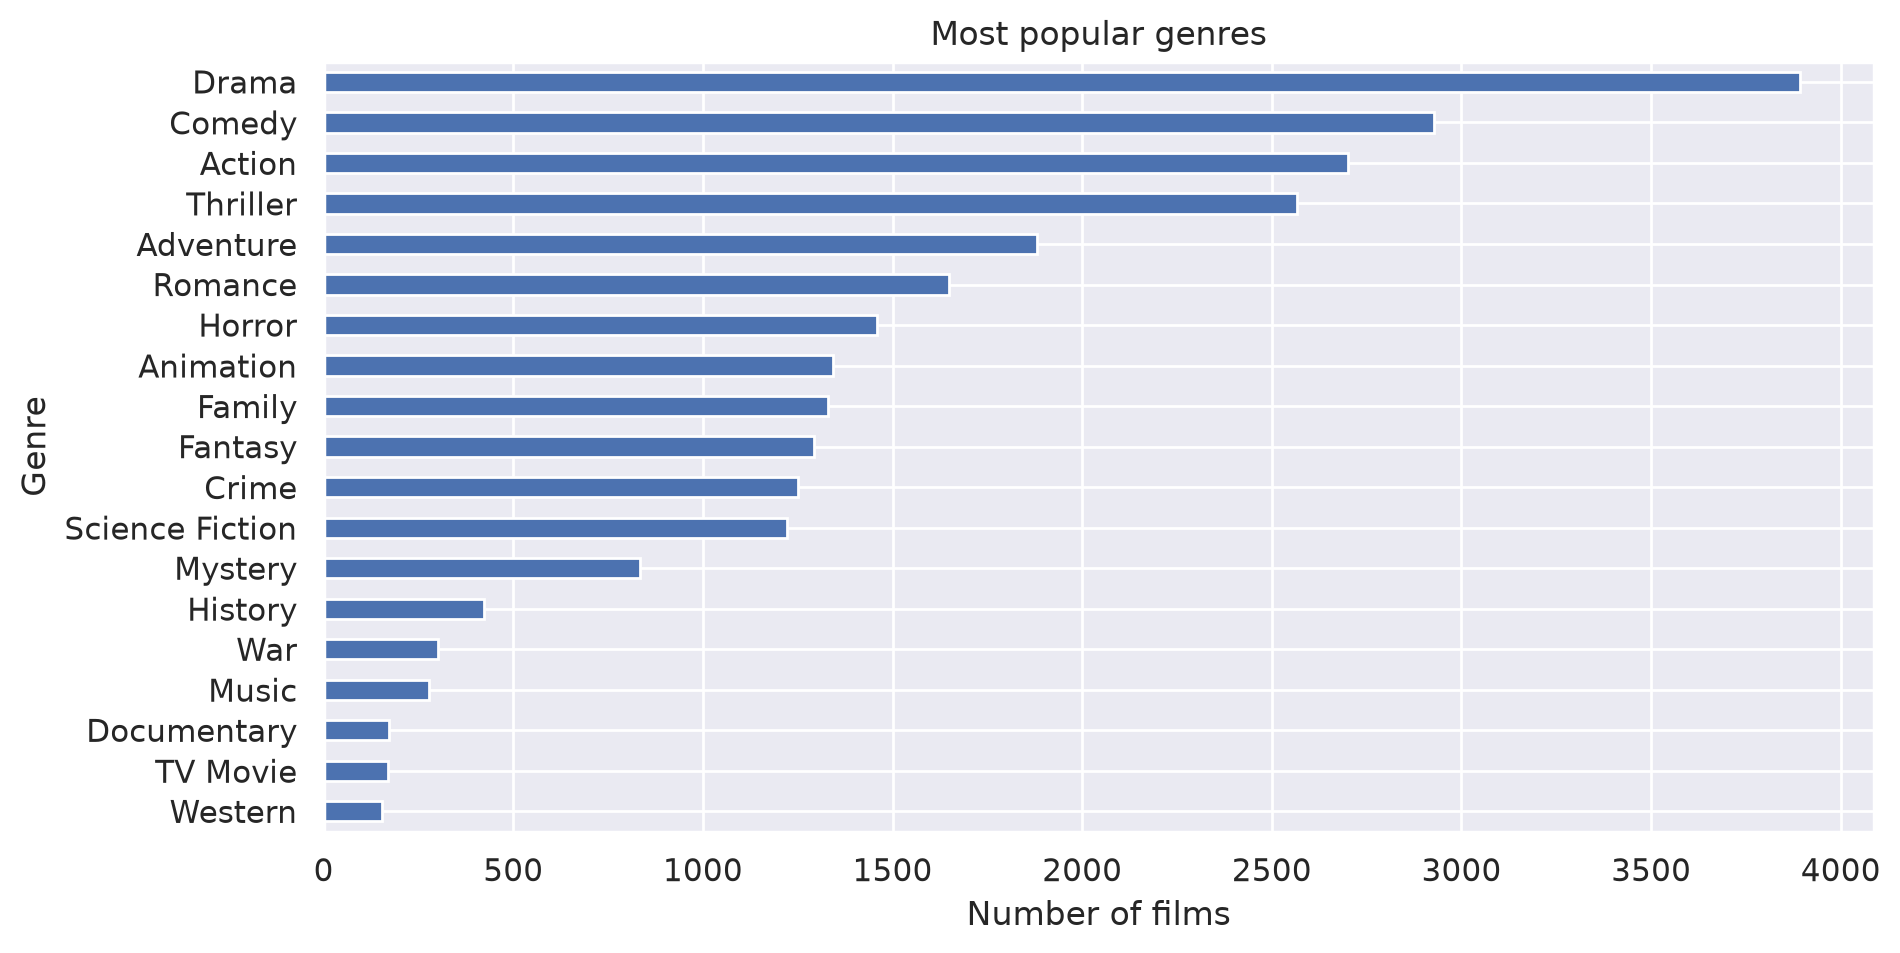

In [51]:
plt.figure(figsize=(10, 5), dpi=200)

ax = (
    df['genres']
    .explode()
    .value_counts()
    .sort_values()
    .plot.barh()
)
ax.set_title('Most popular genres')
ax.set_xlabel('Number of films')
ax.set_ylabel('Genre')

plt.show()

In [52]:
releases_per_year = (
    df['release_year']
    .value_counts()
    .sort_index(ascending=False)
    .to_frame('releases')
    .assign(year=lambda x: x.index)
    .to_numpy()
)
releases, years = releases_per_year.T

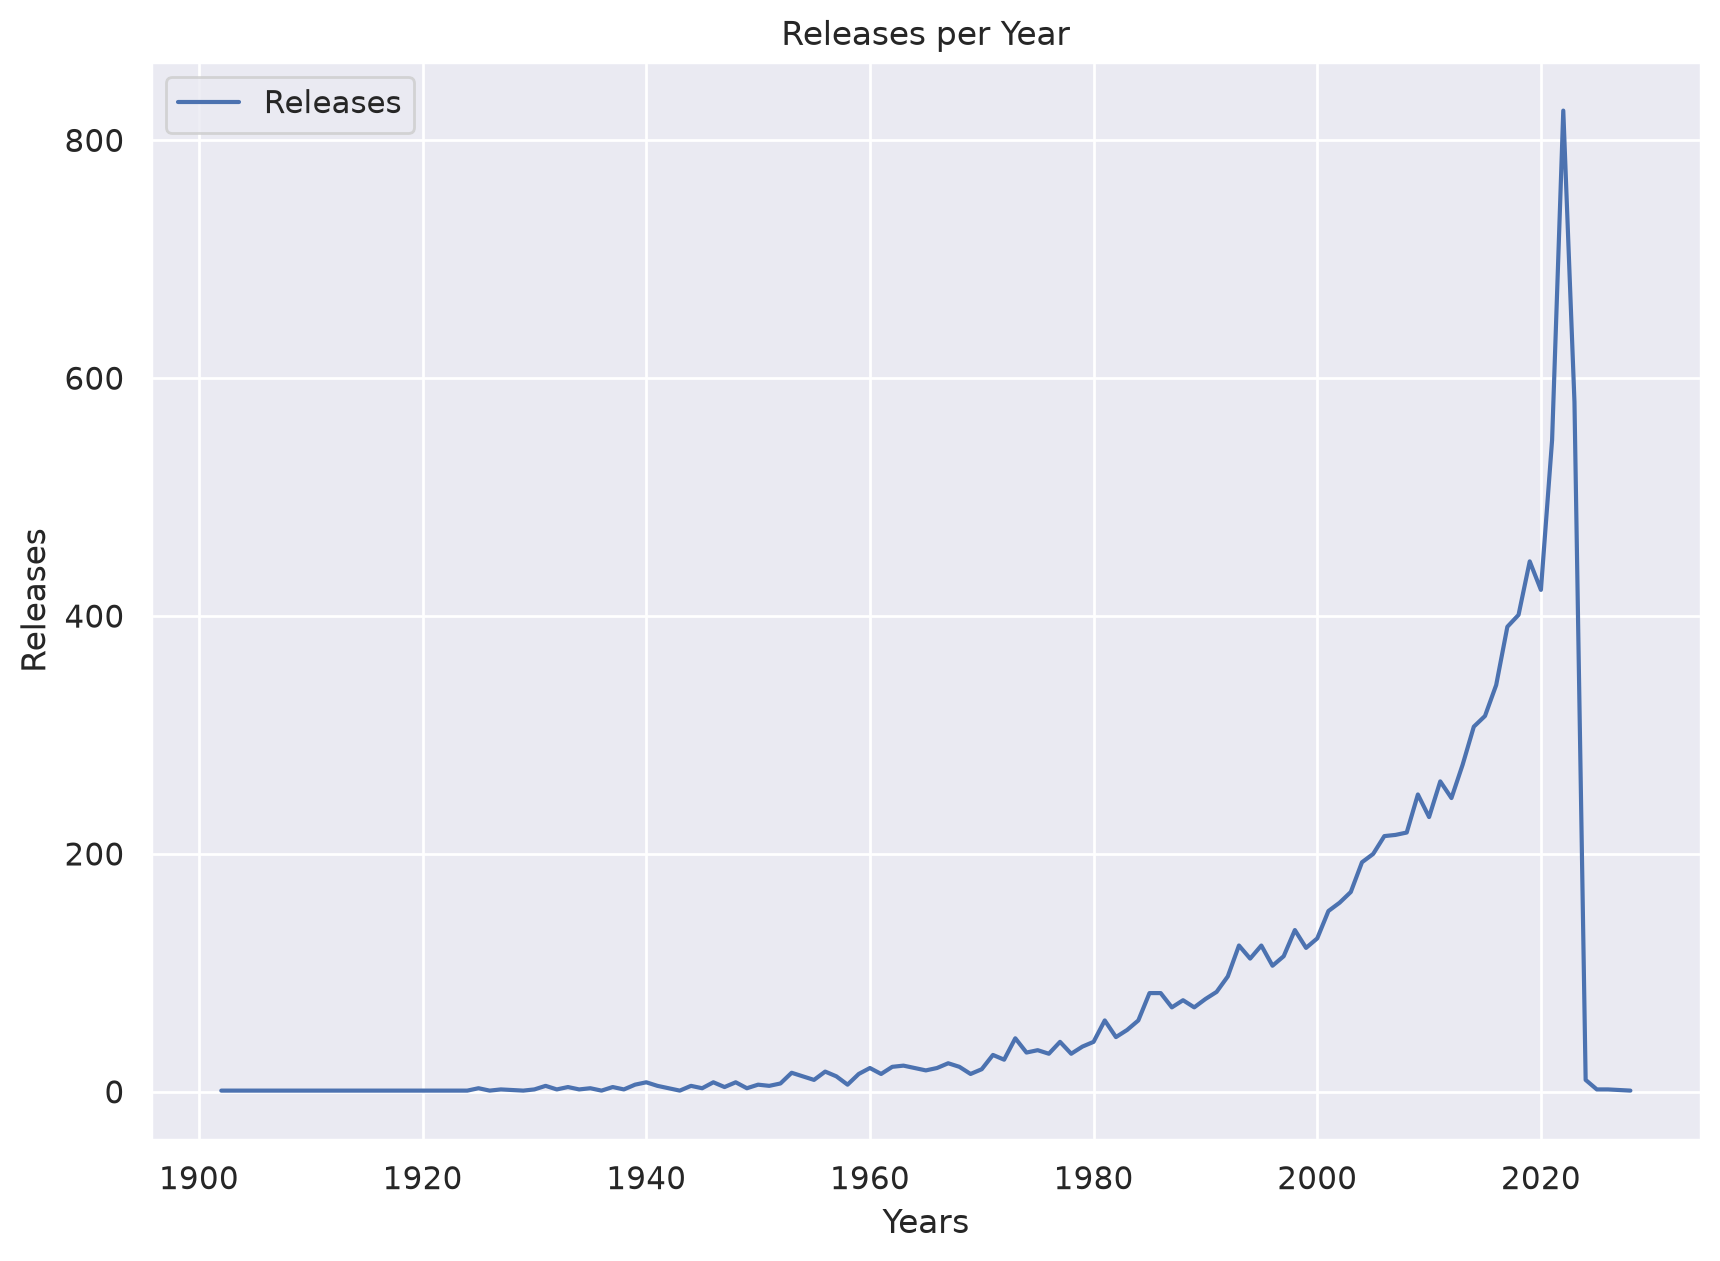

In [53]:
plt.figure(figsize=(10, 7), dpi=200)

plt.title('Releases per Year')
plt.plot(years, releases, label='Releases')

plt.xlabel('Years')
plt.ylabel('Releases')

plt.legend()
plt.show()

In [54]:
votes_df = df[['release_year', 'vote_average']]
votes_df = votes_df.sort_values('release_year')

mean_votes_per_year = votes_df.groupby('release_year').agg({'vote_average': np.mean})
mean_votes, years = mean_votes_per_year.assign(year=lambda x: x.index).to_numpy().T

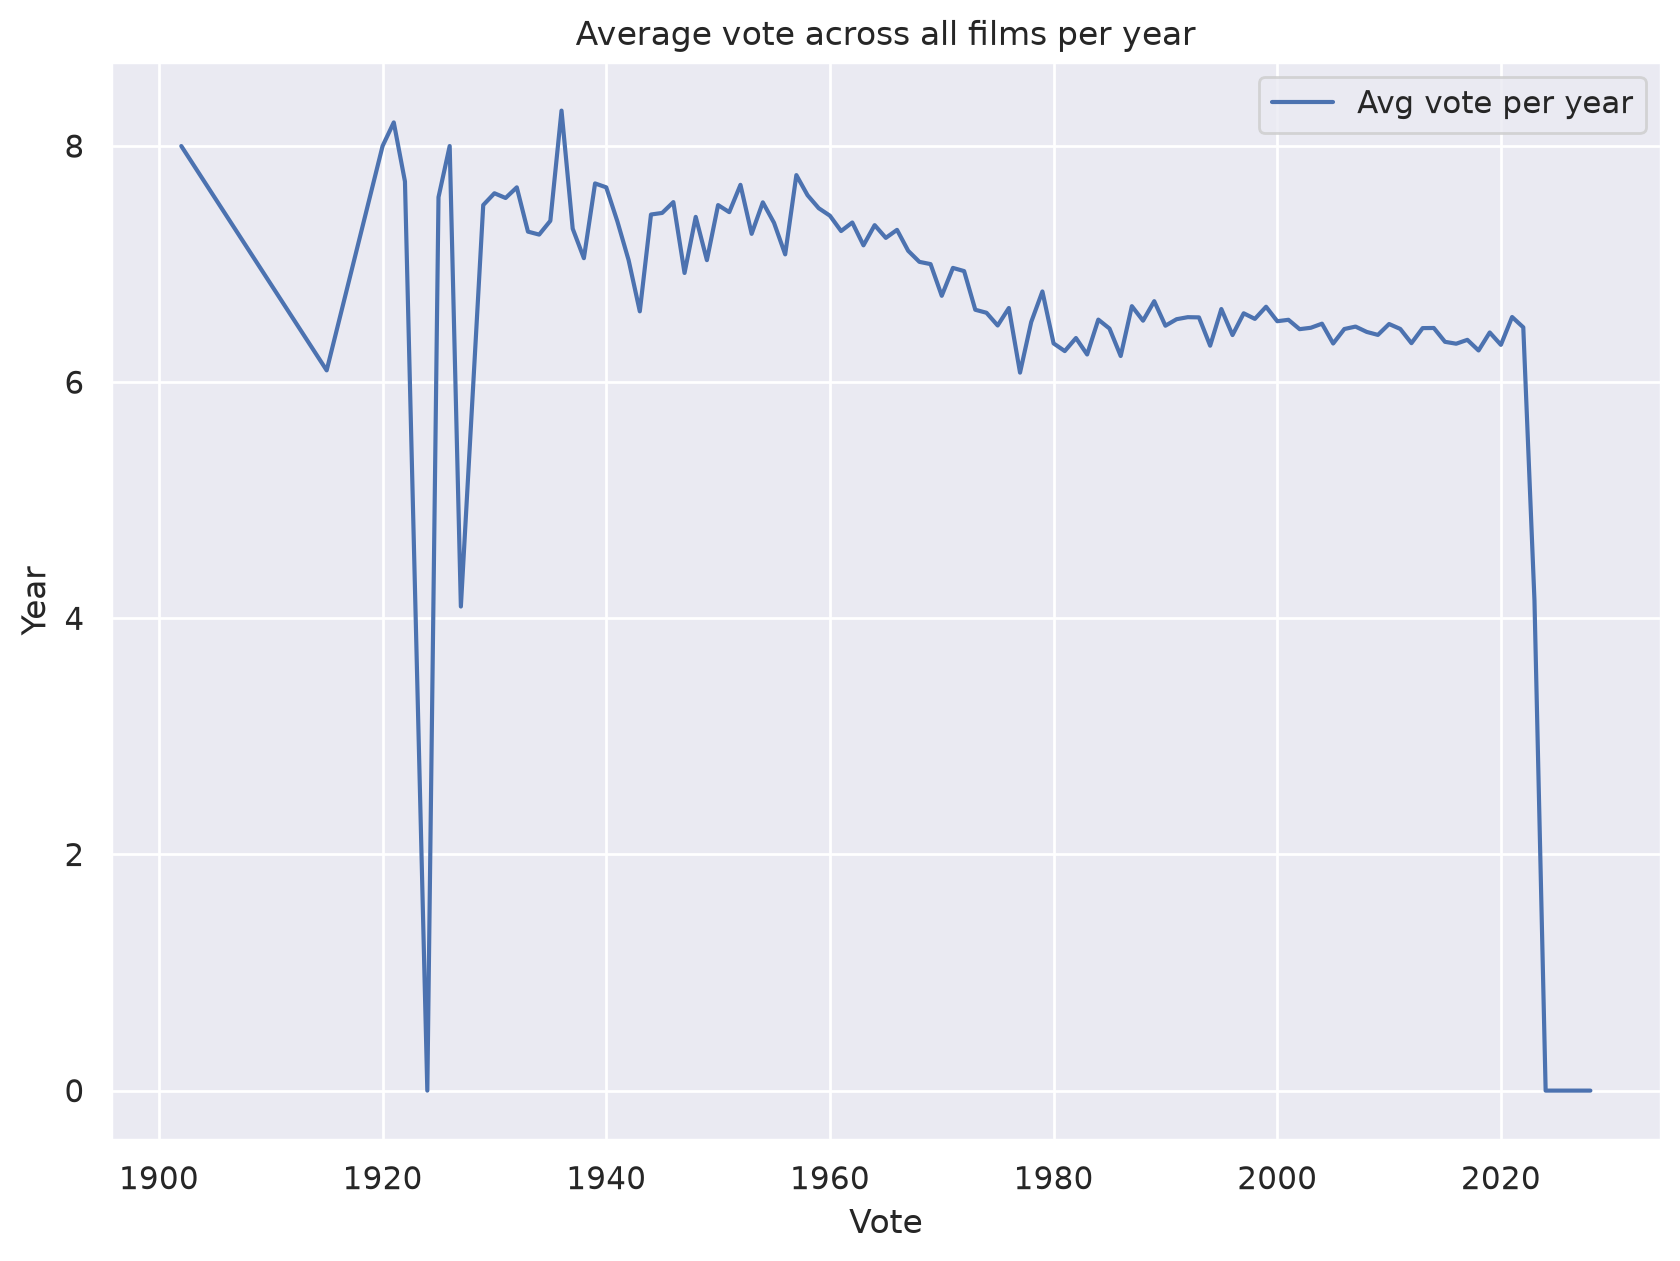

In [55]:
plt.figure(figsize=(10, 7), dpi=200)

plt.title('Average vote across all films per year')
plt.plot(years, mean_votes, label='Avg vote per year')

plt.xlabel('Vote')
plt.ylabel('Year')

plt.legend()
plt.show()

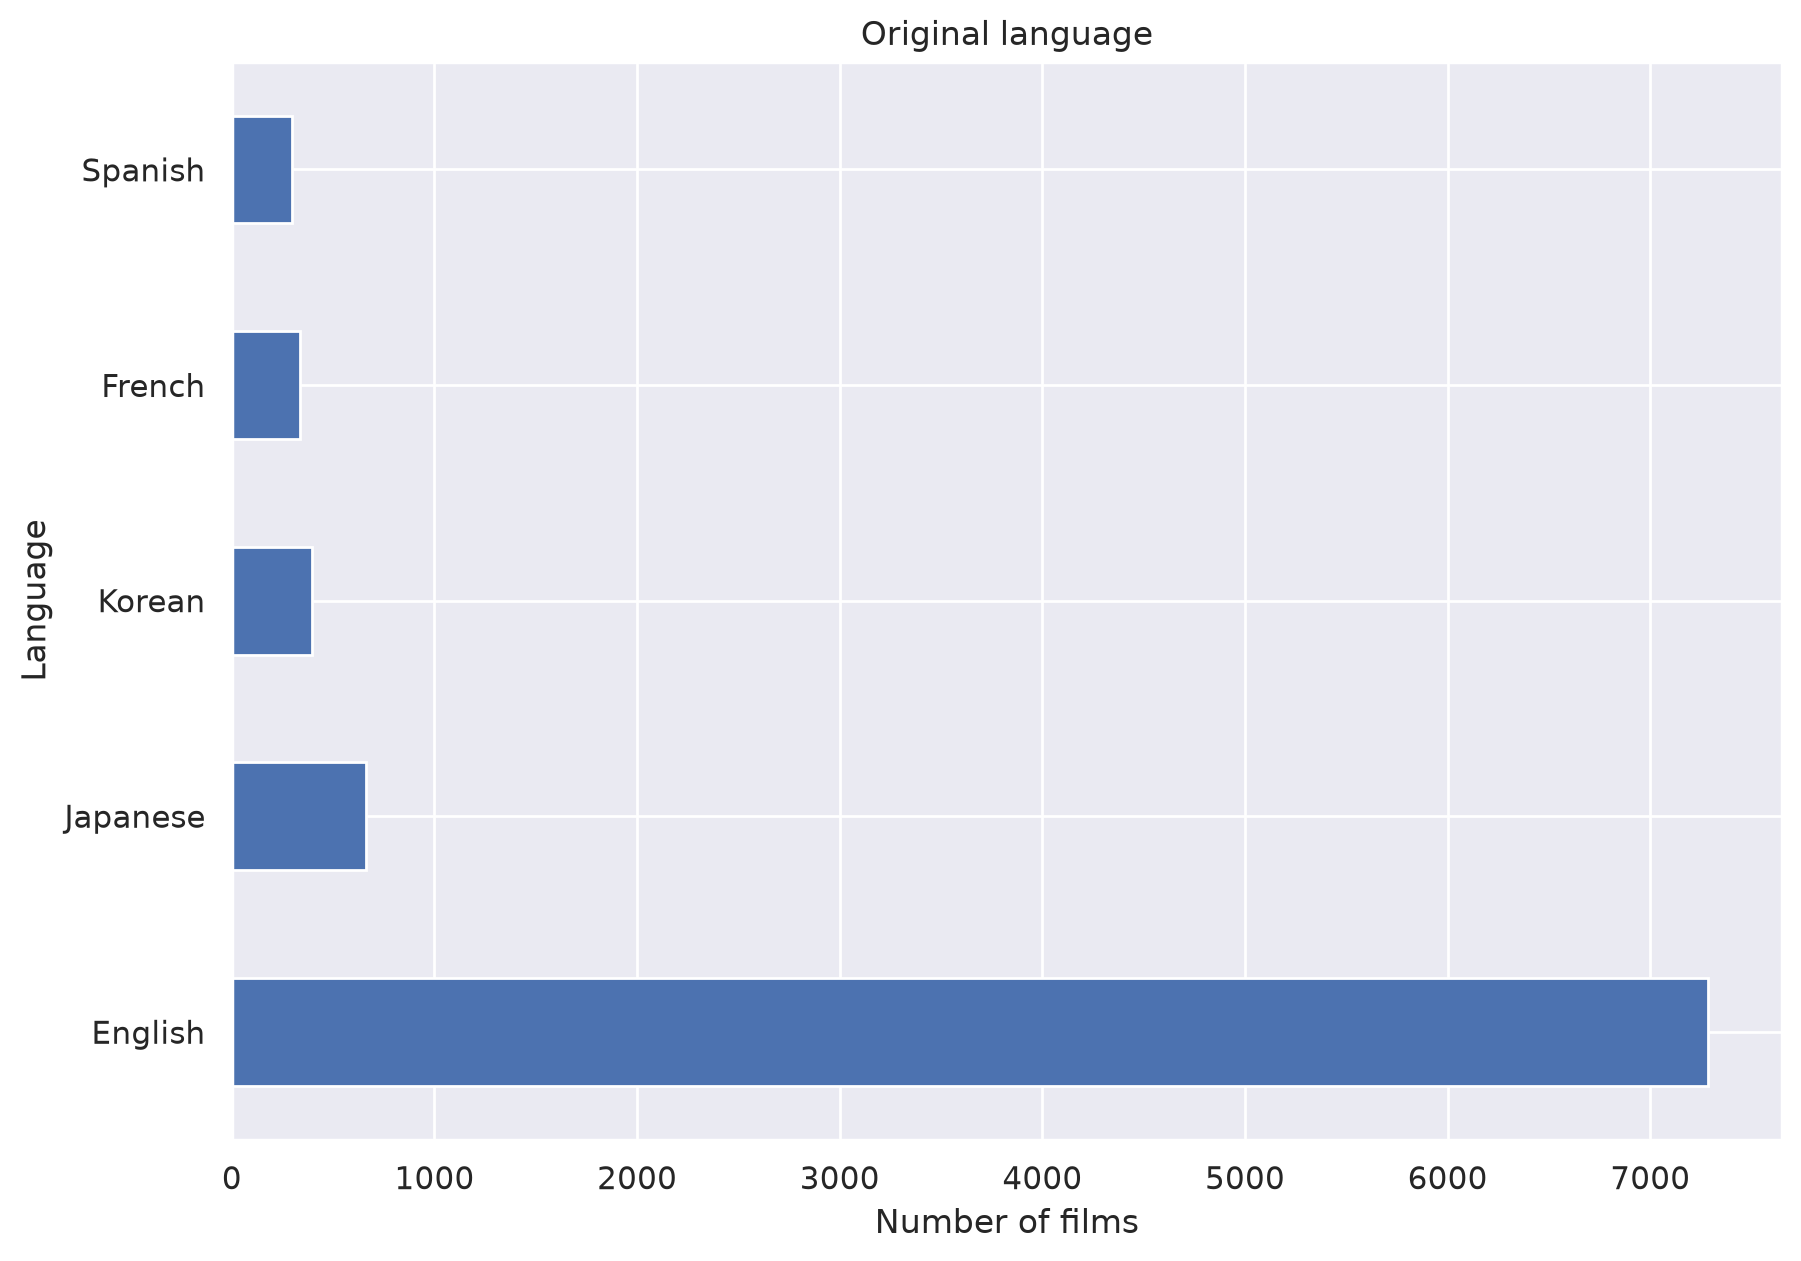

In [56]:
fig = plt.figure(figsize=(10, 7), dpi=200)

ax = df['original_language'].value_counts().head().plot.barh()
ax.set_title('Original language')
ax.set_ylabel('Language')
ax.set_xlabel('Number of films')

plt.show()